# Research Swarm - Multiple Invocations Demo

This notebook demonstrates how to use the Research Swarm with multiple invocations.

**What you'll learn:**
- How to create and initialize the swarm
- Running multiple queries in sequence
- Using thread IDs for conversation continuity
- Extracting and displaying results
- Understanding agent handoffs and collaboration

## Setup

First, let's import required modules and check environment variables.

## Add Project Root to Path

Since this notebook is in a subdirectory, we need to add the project root to Python's path.

In [1]:
import sys
from pathlib import Path

# Add project root to Python path
project_root = Path().absolute().parent
sys.path.insert(0, str(project_root))

print(f"✅ Added to path: {project_root}")

✅ Added to path: /Users/liamnguyen/Documents/0.Coding/langchain-multi-agent-writer


In [2]:
import os
import uuid
from dotenv import load_dotenv
from workflows.research_swarm import create_research_swarm, get_swarm_info
from utils.agent_prompts import clear_prompt_cache

# Load environment variables
load_dotenv()

# Check API keys
if not os.getenv("OPENAI_API_KEY"):
    print("❌ OPENAI_API_KEY not found!")
    print("Please set it in .env file")
else:
    print("✅ OPENAI_API_KEY found")

if not os.getenv("TAVILY_API_KEY"):
    print("⚠️  TAVILY_API_KEY not found - web search may be limited")
else:
    print("✅ TAVILY_API_KEY found")

✅ OPENAI_API_KEY found
✅ TAVILY_API_KEY found


## Understanding the Swarm

Let's first see what agents are available in our swarm.

In [4]:
# Get swarm information
clear_prompt_cache()
swarm_info = get_swarm_info()

print(f"📋 Swarm: {swarm_info['name']}")
print(f"   {swarm_info['description']}\n")
print(f"🤖 Default Agent: {swarm_info['default_agent']}\n")
print(f"👥 Agents ({len(swarm_info['agents'])}):\n")

for agent in swarm_info['agents']:
    print(f"  • {agent['name'].upper()}")
    print(f"    Role: {agent['role']}")
    print(f"    Capabilities:")
    for cap in agent['capabilities']:
        print(f"      - {cap}")
    print()

2025-11-17 23:05:42 | INFO     | utils.agent_prompts | Clearing prompt cache (0 entries)
2025-11-17 23:05:42 | INFO     | agents.agent_factory | Initializing AgentFactory


📋 Swarm: Research Swarm
   Multi-agent system for Vietnamese technical newsletter research

🤖 Default Agent: eic

👥 Agents (3):

  • EIC
    Role: Content planning expert who structures newsletters for maximum engagement. Acts as the Editor-in-Chief orchestrating the content creation workflow.

    Capabilities:
      - Can transfer to research_strategist
      - Can transfer to research_technical

  • RESEARCH_STRATEGIST
    Role: Transform a raw topic request into a detailed, actionable content brief that ensures the final newsletter will be engaging, technically accurate, and match the target Vietnamese audience's needs.

    Capabilities:
      - Has access to: search_web
      - Can transfer to research_technical

  • RESEARCH_TECHNICAL
    Role: Gather deep, accurate technical information, real-world examples, and authoritative sources that enable other agents to create an excellent Vietnamese technical newsletter. The fact-finding specialist who ensures technical credibility.

 

## Create the Swarm

Initialize the Research Swarm application.

In [5]:
print("⚙️  Creating swarm...")
app = create_research_swarm()
print(f"✅ Swarm created successfully!")
print(f"   Type: {type(app).__name__}")

2025-11-17 23:05:45 | INFO     | agents.agent_factory | Initializing AgentFactory
2025-11-17 23:05:45 | INFO     | agents.agent_factory | Creating agent: research_strategist
2025-11-17 23:05:45 | INFO     | agents.agent_factory | Agent 'research_strategist' configured with 1 tools
2025-11-17 23:05:45 | INFO     | utils.agent_prompts | Loading prompt for agent: research_strategist (file: research_strategist_fake.yaml)
2025-11-17 23:05:45 | INFO     | utils.agent_prompts | Prompt cached for agent: research_strategist (240 chars)
2025-11-17 23:05:45 | INFO     | agents.agent_factory | Agent 'research_strategist' created successfully
2025-11-17 23:05:45 | INFO     | agents.agent_factory | Creating agent: research_technical
2025-11-17 23:05:45 | INFO     | agents.agent_factory | Agent 'research_technical' configured with 1 tools
2025-11-17 23:05:45 | INFO     | utils.agent_prompts | Loading prompt for agent: research_technical (file: research_technical_fake.yaml)
2025-11-17 23:05:45 | INFO 

⚙️  Creating swarm...
✅ Swarm created successfully!
   Type: CompiledStateGraph


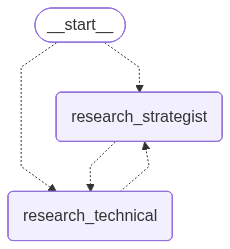

In [6]:
app

## Helper Functions

Let's create some helper functions to display results nicely.

## Example 1: Single Invocation

Let's start with a simple example - a single query to the swarm.

In [7]:
from utils.agent_utils import pretty_print_messages

# Create a unique thread ID for this conversation
thread_id = 1
config = {"configurable": {"thread_id": thread_id}}

print(f"🔖 Thread ID: {thread_id}")

# Define the query
query = "Create a brief for Apache Kafka for Vietnamese developers in 3 sentences"

# Invoke the swarm
result = app.invoke(
    {"messages": [{"role": "user", "content": query}]},
    config
)

pretty_print_messages(result)

🔖 Thread ID: 1


2025-11-17 23:05:57 | INFO     | utils.agent_utils | Displaying 2 messages for active agent: Unknown



ACTIVE AGENT: UNKNOWN

👤 USER:
   Create a brief for Apache Kafka for Vietnamese developers in 3 sentences

🤖 UNKNOWN:
   Apache Kafka là một nền tảng xử lý luồng dữ liệu phân tán mã nguồn mở, được thiết kế để xử lý dữ liệu theo thời gian thực với khả năng mở rộng cao và độ tin cậy. Được phát triển bởi LinkedIn và sau đó trở thành một dự án hàng đầu của Apache, Kafka hỗ trợ các nhà phát triển trong việc xây dựng các ứng dụng có khả năng xử lý hàng triệu sự kiện mỗi giây. Trong bối cảnh công nghệ hiện đại, Kafka thường được sử dụng cho việc phân tích dữ liệu thời gian thực, tích hợp dữ liệu và xây dựng các hệ thống ...
   [... 14 more characters]




In [23]:
from langchain_openai import ChatOpenAI

from langgraph.checkpoint.memory import InMemorySaver
from langchain.agents import create_agent
from langgraph_swarm import create_handoff_tool, create_swarm

model = ChatOpenAI(model="gpt-4o")

def add(a: int, b: int) -> int:
    """Add two numbers"""
    return a + b

alice = create_agent(
    model,
    [add, create_handoff_tool(agent_name="Bob")],
    system_prompt="You are Alice, an addition expert.",
    name="Alice",
)

bob = create_agent(
    model,
    [create_handoff_tool(agent_name="Alice", description="Transfer to Alice, she can help with math")],
    system_prompt="You are Bob, you speak like a pirate.",
    name="Bob",
)

checkpointer = InMemorySaver()
workflow = create_swarm(
    [alice, bob],
    default_active_agent="Alice"
)
app = workflow.compile(checkpointer=checkpointer)

config = {"configurable": {"thread_id": "1"}}
turn_1 = app.invoke(
    {"messages": [{"role": "user", "content": "i'd like to speak to Bob"}]},
    config,
)
pretty_print_messages(turn_1)
turn_2 = app.invoke(
    {"messages": [{"role": "user", "content": "what's 5 + 7?"}]},
    config,
)
pretty_print_messages(turn_2)


ACTIVE AGENT: BOB

👤 USER:
   i'd like to speak to Bob

🤖 UNKNOWN:
   🔄 Transferring to Bob...

⚙️  TOOL RESULT (transfer_to_bob):
   Successfully transferred to Bob

🤖 UNKNOWN:
   Ahoy, matey! Bob be at ye service. What seas be ye navigatin' today?



ACTIVE AGENT: ALICE

👤 USER:
   i'd like to speak to Bob

🤖 UNKNOWN:
   🔄 Transferring to Bob...

⚙️  TOOL RESULT (transfer_to_bob):
   Successfully transferred to Bob

🤖 UNKNOWN:
   Ahoy, matey! Bob be at ye service. What seas be ye navigatin' today?

👤 USER:
   what's 5 + 7?

🤖 UNKNOWN:
   🔄 Transferring to Alice...

⚙️  TOOL RESULT (transfer_to_alice):
   Successfully transferred to Alice

🤖 UNKNOWN:
   🔧 Using tool: add
      {'a': 5, 'b': 7}

⚙️  TOOL RESULT (add):
   12

🤖 UNKNOWN:
   The result of 5 + 7 is 12.




In [24]:
turn_1

{'messages': [HumanMessage(content="i'd like to speak to Bob", additional_kwargs={}, response_metadata={}, id='4e0299cf-ddab-427c-a224-aca4bdff524a'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 12, 'prompt_tokens': 77, 'total_tokens': 89, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_b1442291a8', 'id': 'chatcmpl-CcuzWz7GQYVyiOX8OU4p5Yl5cBmZE', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--7af97bce-2251-4565-b917-2a39d1ca45c9-0', tool_calls=[{'name': 'transfer_to_bob', 'args': {}, 'id': 'call_5pzpXokdHHy3wJBNgjD7drmB', 'type': 'tool_call'}], usage_metadata={'input_tokens': 77, 'output_tokens': 12, 'total_tokens': 89, 'input_tok

In [25]:
turn_2

{'messages': [HumanMessage(content="i'd like to speak to Bob", additional_kwargs={}, response_metadata={}, id='4e0299cf-ddab-427c-a224-aca4bdff524a'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 12, 'prompt_tokens': 77, 'total_tokens': 89, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_b1442291a8', 'id': 'chatcmpl-CcuzWz7GQYVyiOX8OU4p5Yl5cBmZE', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--7af97bce-2251-4565-b917-2a39d1ca45c9-0', tool_calls=[{'name': 'transfer_to_bob', 'args': {}, 'id': 'call_5pzpXokdHHy3wJBNgjD7drmB', 'type': 'tool_call'}], usage_metadata={'input_tokens': 77, 'output_tokens': 12, 'total_tokens': 89, 'input_tok

In [7]:
result

{'messages': [HumanMessage(content='Create a brief for Apache Kafka for Vietnamese developers in 3 sentences', additional_kwargs={}, response_metadata={}, id='631e39c1-e51e-40d4-83c3-d75d9ee5e1b0'),
  AIMessage(content='Apache Kafka là một nền tảng xử lý luồng dữ liệu phân tán mạnh mẽ, được thiết kế để xử lý dữ liệu theo thời gian thực với khả năng mở rộng cao và độ tin cậy. Được sử dụng rộng rãi trong các hệ thống lớn, Kafka cho phép truyền tải và xử lý lượng dữ liệu lớn một cách hiệu quả giữa các ứng dụng và dịch vụ. Bài viết này sẽ khám phá các khái niệm cơ bản, kiến trúc, và các trường hợp sử dụng phổ biến của Apache Kafka, cùng với các hướng dẫn triển khai cho các nhà phát triển tại Việt Nam.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 129, 'prompt_tokens': 102, 'total_tokens': 231, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tok

### Extract Final Response

Let's see just the final AI response.


## Example 2: Multiple Sequential Invocations

Now let's run multiple queries in sequence. **Important**: Each query gets its own thread to avoid message history conflicts.

In [ ]:
# Define multiple queries
queries = [
    "What are the key components of Apache Kafka architecture?",
    "Compare Kafka with RabbitMQ for stream processing",
    "What are best practices for Kafka topic design?"
]

print(f"📋 Running {len(queries)} queries (each with separate thread)...\n")

results = []

for i, query in enumerate(queries, 1):
    # Create NEW thread for each query to avoid message conflicts
    thread_id = str(uuid.uuid4())
    config = {"configurable": {"thread_id": thread_id}}
    
    print_separator()
    print(f"Query {i}/{len(queries)}: {query}")
    print(f"Thread: {thread_id[:8]}...")
    print_separator()
    
    # Invoke swarm
    result = app.invoke(
        {"messages": [{"role": "user", "content": query}]},
        config
    )
    
    messages = result.get("messages", [])
    active_agent = result.get("active_agent", "unknown")
    
    print(f"\n✅ Completed")
    print(f"   Messages: {len(messages)}")
    print(f"   Active Agent: {active_agent}")
    
    # Store result
    results.append({
        "query": query,
        "thread_id": thread_id,
        "messages": messages,
        "active_agent": active_agent,
        "response": get_final_response(messages)
    })
    
    print()

print_separator()
print(f"✅ All {len(queries)} queries completed!")
print_separator()

In [ ]:
# Define multiple queries
queries = [
    "What are the key components of Apache Kafka architecture?",
    "Compare Kafka with RabbitMQ for stream processing",
    "What are best practices for Kafka topic design?"
]

# New thread for these queries
thread_id_multi = str(uuid.uuid4())
config_multi = {"configurable": {"thread_id": thread_id_multi}}

print(f"🔖 Thread ID: {thread_id_multi}")
print(f"📋 Running {len(queries)} queries...\n")

results = []

for i, query in enumerate(queries, 1):
    print_separator()
    print(f"Query {i}/{len(queries)}: {query}")
    print_separator()
    
    # Invoke swarm
    result = app.invoke(
        {"messages": [{"role": "user", "content": query}]},
        config_multi
    )
    
    messages = result.get("messages", [])
    active_agent = result.get("active_agent", "unknown")
    
    print(f"\n✅ Completed")
    print(f"   Messages: {len(messages)}")
    print(f"   Active Agent: {active_agent}")
    
    # Store result
    results.append({
        "query": query,
        "messages": messages,
        "active_agent": active_agent,
        "response": get_final_response(messages)
    })
    
    print()

print_separator()
print(f"✅ All {len(queries)} queries completed!")
print_separator()

print("\n📊 RESULTS SUMMARY\n")

for i, result in enumerate(results, 1):
    print(f"{i}. Query: {result['query']}")
    print(f"   Thread: {result['thread_id'][:16]}...")
    print(f"   Agent: {result['active_agent']}")
    print(f"   Messages: {len(result['messages'])}")
    print(f"   Response preview: {result['response'][:150] if result['response'] else 'No response'}...")
    print()

In [ ]:
print("\n📊 RESULTS SUMMARY\n")

for i, result in enumerate(results, 1):
    print(f"{i}. Query: {result['query']}")
    print(f"   Agent: {result['active_agent']}")
    print(f"   Messages: {len(result['messages'])}")
    print(f"   Response preview: {result['response'][:150] if result['response'] else 'No response'}...")
    print()

### View Individual Results

Pick a specific result to view in detail.

In [ ]:
# Change this to view different results (0, 1, or 2)
result_index = 0

result = results[result_index]

print_separator()
print(f"📄 Result #{result_index + 1}")
print_separator()
print(f"Query: {result['query']}\n")
print(f"Agent: {result['active_agent']}\n")
print_separator("-")
print("Response:")
print_separator("-")
print(result['response'])

## Example 3: Conversation with Context (Same Thread)

When using the same thread ID, the swarm maintains conversation context. Let's try follow-up questions.

In [ ]:
# Create new thread for conversation
thread_id_conv = str(uuid.uuid4())
config_conv = {"configurable": {"thread_id": thread_id_conv}}

print(f"🔖 Thread ID: {thread_id_conv}\n")

# Initial query
print_separator()
print("Initial Query")
print_separator()

initial_query = "Tell me about Apache Kafka"
print(f"👤 User: {initial_query}\n")

result1 = app.invoke(
    {"messages": [{"role": "user", "content": initial_query}]},
    config_conv
)

response1 = get_final_response(result1.get("messages", []))
print(f"🤖 Response: {response1[:200]}...\n")

In [ ]:
# Follow-up query (using same thread ID)
print_separator()
print("Follow-up Query (maintains context)")
print_separator()

followup_query = "What are its main components?"
print(f"👤 User: {followup_query}\n")

result2 = app.invoke(
    {"messages": [{"role": "user", "content": followup_query}]},
    config_conv  # Same thread!
)

response2 = get_final_response(result2.get("messages", []))
print(f"🤖 Response: {response2[:200]}...\n")

### Important Note: Thread Context vs. Fresh Queries

**When to use the same thread:**
- ✅ Follow-up questions that reference previous context
- ✅ Conversational flows where history matters
- ✅ Example: "Tell me about X" → "What are its components?" → "Compare it with Y"

**When to use separate threads:**
- ✅ Independent queries that don't need shared context
- ✅ Batch processing of different topics
- ✅ When agent handoffs create complex message histories
- ✅ Example: Multiple unrelated research queries

**Why separate threads for Example 2:**
When agents hand off to each other (e.g., research_strategist → research_technical), the message history can accumulate tool calls and responses. Reusing the same thread for multiple independent queries can cause OpenAI API errors about orphaned tool messages.

In [ ]:
# Another follow-up
print_separator()
print("Another Follow-up")
print_separator()

followup_query2 = "How does it compare to RabbitMQ?"
print(f"👤 User: {followup_query2}\n")

result3 = app.invoke(
    {"messages": [{"role": "user", "content": followup_query2}]},
    config_conv  # Same thread!
)

response3 = get_final_response(result3.get("messages", []))
print(f"🤖 Response: {response3[:200]}...\n")

print("\n💡 Note: All three queries used the same thread ID, so context was maintained!")

## Example 4: Using Stream for Real-time Updates

Instead of `invoke()`, we can use `stream()` to see updates as they happen.

In [ ]:
# New thread for streaming
thread_id_stream = str(uuid.uuid4())
config_stream = {"configurable": {"thread_id": thread_id_stream}}

query = "What is Redis and how is it used?"

print_separator()
print(f"📝 Query: {query}")
print_separator()
print("\n🔄 Streaming updates...\n")

# Stream the response
update_count = 0
for ns, update in app.stream(
    {"messages": [{"role": "user", "content": query}]},
    config_stream,
    subgraphs=True,
):
    update_count += 1
    print(f"📦 Update {update_count}: {ns}")

print(f"\n✅ Received {update_count} updates")

# Get final state
state = app.get_state(config_stream)
if hasattr(state, "values"):
    messages = state.values.get("messages", [])
    print(f"📨 Final message count: {len(messages)}")
    
    # Show final response
    final = get_final_response(messages)
    print("\n" + "="*80)
    print("Final Response:")
    print("="*80)
    print(final)

## Example 5: Batch Processing Multiple Topics

Process multiple different topics and collect all results.

In [ ]:
# Define topics to research
topics = [
    "Apache Flink",
    "Redis",
    "PostgreSQL",
]

print(f"📚 Processing {len(topics)} topics...\n")

# Each topic gets its own thread
topic_results = []

for i, topic in enumerate(topics, 1):
    # New thread for each topic
    thread_id = str(uuid.uuid4())
    config = {"configurable": {"thread_id": thread_id}}
    
    query = f"Create a brief about {topic} for Vietnamese developers"
    
    print(f"[{i}/{len(topics)}] Processing: {topic}")
    print(f"   Thread: {thread_id[:8]}...")
    
    try:
        result = app.invoke(
            {"messages": [{"role": "user", "content": query}]},
            config
        )
        
        messages = result.get("messages", [])
        response = get_final_response(messages)
        
        topic_results.append({
            "topic": topic,
            "thread_id": thread_id,
            "success": True,
            "messages": messages,
            "response": response
        })
        
        print(f"   ✅ Success ({len(messages)} messages)\n")
        
    except Exception as e:
        print(f"   ❌ Error: {e}\n")
        topic_results.append({
            "topic": topic,
            "thread_id": thread_id,
            "success": False,
            "error": str(e)
        })

print_separator()
print("✅ Batch processing complete!")
print_separator()

## Summary

You've learned how to:

1. ✅ **Single Invocation** - Basic query to the swarm
2. ✅ **Multiple Sequential Invocations** - Running multiple independent queries (separate threads)
3. ✅ **Conversation Context** - Using same thread ID for follow-up questions
4. ✅ **Streaming Updates** - Using `stream()` for real-time updates
5. ✅ **Batch Processing** - Processing multiple topics efficiently

## Key Concepts

- **Thread ID**: Maintains conversation context
  - **Same thread** = shared history (for conversations with follow-ups)
  - **Different threads** = fresh start (for independent queries)
- **`invoke()`**: Blocking call that returns final result
- **`stream()`**: Returns updates as they happen
- **Agent Handoffs**: Agents transfer control to each other automatically
- **Messages**: All interactions stored as messages in the thread

## Important Threading Guidelines

### ✅ Use SAME thread for:
- Follow-up questions: "What is X?" → "Tell me more about its components"
- Conversational context: "Compare A with B" → "Which is better for my use case?"

### ✅ Use SEPARATE threads for:
- Independent queries: "About Kafka", "About Redis", "About PostgreSQL"
- Batch processing: Multiple unrelated topics
- Avoiding message conflicts: When you get tool message errors

### ⚠️ Common Error:
```
BadRequestError: messages with role 'tool' must be a response to a preceeding message with 'tool_calls'
```
**Solution**: Use a new thread ID for each independent query (see Example 2)

## Next Steps

- Explore `notebooks/agent_system_walkthrough.ipynb` for architecture details
- Check `config/agents.yaml` to see agent configurations
- Try the Streamlit app: `streamlit run research_swarm_app.py`
- Modify agents in `agents/` directory
- Add custom tools in `tools/` directory

In [ ]:
print("\n📊 BATCH RESULTS\n")

for i, result in enumerate(topic_results, 1):
    status = "✅" if result["success"] else "❌"
    print(f"{status} {i}. {result['topic']}")
    print(f"   Thread: {result['thread_id'][:16]}...")
    
    if result["success"]:
        print(f"   Messages: {len(result['messages'])}")
        print(f"   Preview: {result['response'][:100]}...")
    else:
        print(f"   Error: {result['error']}")
    print()

## Summary

You've learned how to:

1. ✅ **Single Invocation** - Basic query to the swarm
2. ✅ **Multiple Sequential Invocations** - Running multiple independent queries
3. ✅ **Conversation Context** - Using same thread ID for follow-up questions
4. ✅ **Streaming Updates** - Using `stream()` for real-time updates
5. ✅ **Batch Processing** - Processing multiple topics efficiently

## Key Concepts

- **Thread ID**: Maintains conversation context. Same thread = shared history, different thread = fresh start
- **`invoke()`**: Blocking call that returns final result
- **`stream()`**: Returns updates as they happen
- **Agent Handoffs**: Agents transfer control to each other automatically
- **Messages**: All interactions stored as messages in the thread

## Next Steps

- Explore `notebooks/agent_system_walkthrough.ipynb` for architecture details
- Check `config/agents.yaml` to see agent configurations
- Try the Streamlit app: `streamlit run research_swarm_app.py`
- Modify agents in `agents/` directory
- Add custom tools in `tools/` directory